## Importing Required Libraries and Loading CSV's 

In [2]:
#importing libraries and loading csv's
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#loading all 9 csv
c_d = pd.read_csv('CSV Files/olist_customers_dataset.csv')
g_d = pd.read_csv('CSV Files/olist_geolocation_dataset.csv')
o_i_d = pd.read_csv('CSV Files/olist_order_items_dataset.csv')
o_p_d = pd.read_csv('CSV Files/olist_order_payments_dataset.csv')
o_r_d = pd.read_csv('CSV Files/olist_order_reviews_dataset.csv')
o_d = pd.read_csv('CSV Files/olist_orders_dataset.csv')
p_d = pd.read_csv('CSV Files/olist_products_dataset.csv')
s_d = pd.read_csv('CSV Files/olist_sellers_dataset.csv')
p_c_n_t = pd.read_csv('CSV Files/product_category_name_translation.csv') 

## Data EDA phase 

In [3]:
temp_dict = {
    'olist_customers_dataset': c_d,
    'olist_geolocation_dataset': g_d,
    'olist_order_items_dataset': o_i_d,
    'olist_order_payments_dataset': o_p_d,
    'olist_order_reviews_dataset': o_r_d,
    'olist_orders_dataset': o_d,
    'olist_products_dataset': p_d,
    'olist_sellers_dataset': s_d,
    'product_category_name_translation': p_c_n_t
}
for i in temp_dict:
    print(f"\n----{i}----")
    print(f"{i} shape: {temp_dict[i].shape}")
    print(f"\n{temp_dict[i].isnull().sum()}")


----olist_customers_dataset----
olist_customers_dataset shape: (99441, 5)

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

----olist_geolocation_dataset----
olist_geolocation_dataset shape: (1000163, 5)

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

----olist_order_items_dataset----
olist_order_items_dataset shape: (112650, 7)

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

----olist_order_payments_dataset----
olist_order_payments_dataset shape: (103886, 5)

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

-

## Data Cleaning 

In [4]:
# checking order status and then deleting required values
print(temp_dict['olist_orders_dataset']['order_status'].value_counts())
clean_values = o_d[~o_d['order_status'].isin(['canceled', 'unavailable'])].copy()
print(clean_values['order_status'].value_counts())
print(clean_values.shape)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
order_status
delivered     96478
shipped        1107
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64
(98207, 8)


In [5]:
# droppping off the required columns 
clean_values = clean_values[~((clean_values['order_status'] == 'delivered')&(clean_values['order_delivered_customer_date'].isnull()))]
print(clean_values['order_status'].value_counts())
print(clean_values.shape)

order_status
delivered     96470
shipped        1107
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64
(98199, 8)


## Converting to date columns to datetime

In [6]:
## olists_order_dataset
date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date']
for col in date_columns:
    clean_values[col] = pd.to_datetime(clean_values[col])
print(clean_values.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [7]:
#creating df for actual delivery date 
clean_values['actual_delivery_date'] = (clean_values['order_delivered_customer_date'] - clean_values['order_estimated_delivery_date']).dt.days
print(clean_values['actual_delivery_date'].head(10))

0    -8.0
1    -6.0
2   -18.0
3   -13.0
4   -10.0
5    -6.0
6     NaN
7   -12.0
8   -32.0
9    -7.0
Name: actual_delivery_date, dtype: float64


In [8]:
# merging product category name 
merged_df = pd.merge(p_d, p_c_n_t, on= "product_category_name")
print(merged_df.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  \
0             225.0               16.0               10.0              14.0   
1            1000.0     

In [9]:
#merging required data
# orders → items (links to products & sellers)
master_df = pd.merge(clean_values, o_i_d, on='order_id', how='left')

# products (with english category names)
master_df = pd.merge(master_df, merged_df, on='product_id', how='left')

# sellers
master_df = pd.merge(master_df, s_d, on='seller_id', how='left')

# customers
master_df = pd.merge(master_df, c_d, on='customer_id', how='left')

# payments
master_df = pd.merge(master_df, o_p_d, on='order_id', how='left')

# reviews
master_df = pd.merge(master_df, o_r_d, on='order_id', how='left')

print(master_df.shape)
print(master_df.columns.tolist())

(117733, 41)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'actual_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


## EDA and Chart Phases

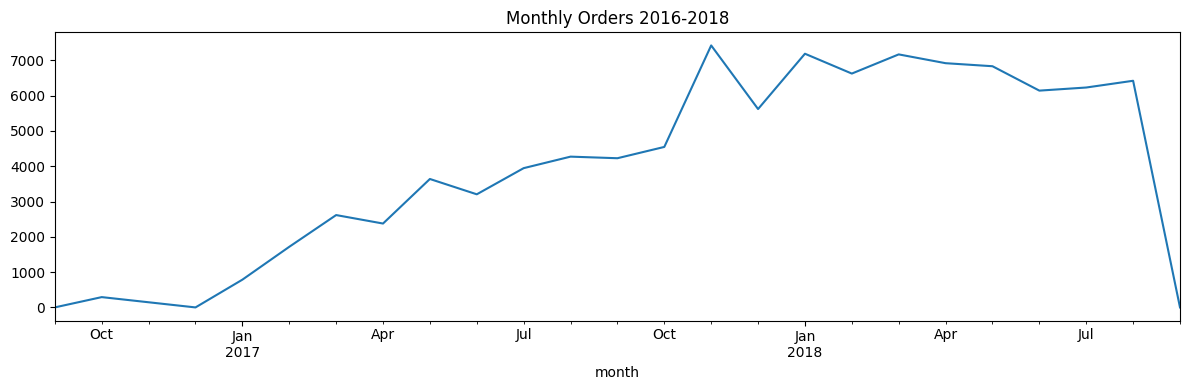

In [24]:
clean_values['month'] = clean_values['order_purchase_timestamp'].dt.to_period('M')
monthly = clean_values.groupby('month').size()
monthly.plot(kind='line', figsize=(12,4), title='Monthly Orders 2016-2018')
plt.tight_layout()
plt.show()

1. The sales peaked in the month of NOV 2017.
2. The data being dropped at the end of the chart, due to data limitation from 2016-2018.

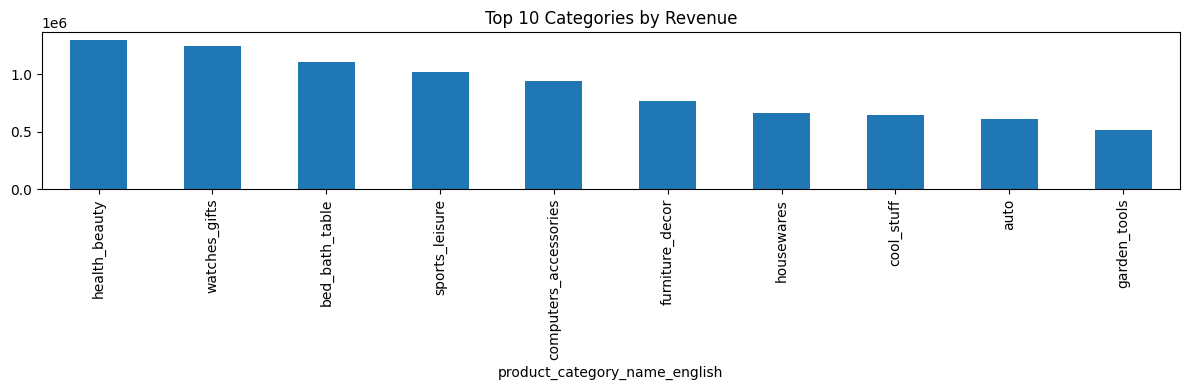

In [25]:
cat_rev = master_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
cat_rev.plot(kind='bar', figsize=(12,4), title='Top 10 Categories by Revenue')
plt.tight_layout()
plt.show()

1. The top most categories by revenue are - health_beauty and watches_gifts which leads me to that ecommerce platform sell most of the beauty products followed by gifts and watches which leads to the conclusion that you will find most of the health and beauty products on this platform which provides most of the benefit to this ecommerce platform

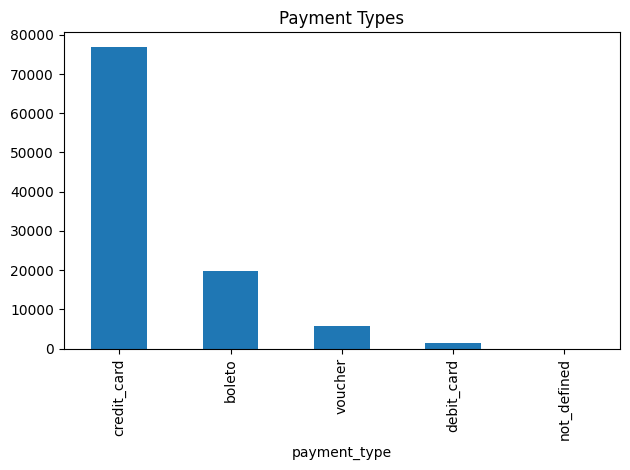

In [26]:
o_p_d['payment_type'].value_counts().plot(kind='bar', title='Payment Types')
plt.tight_layout()
plt.show()

1. The chart shows that the highest payments are made with credit cards followed by boleto.

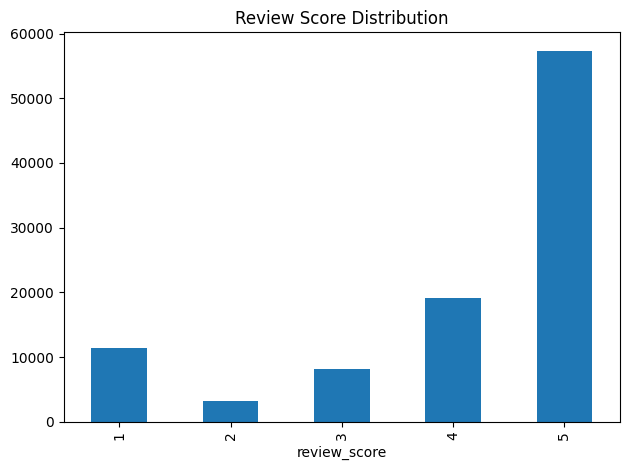

In [27]:
o_r_d['review_score'].value_counts().sort_index().plot(kind='bar', title='Review Score Distribution')
plt.tight_layout()
plt.show()

1. The customers that like the product give 5 score to product 
2. If they dont like it, they either give it 4 score 
3. The 2 score is given by least people cause there are less products that lie in the category of being just above the worst review category 

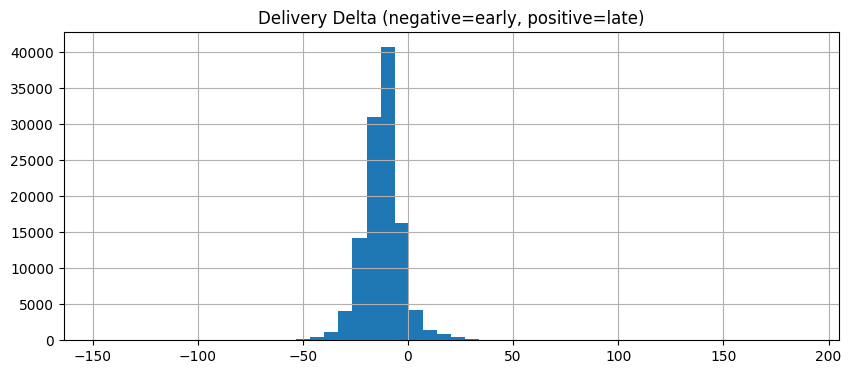

count    115715.000000
mean        -12.047289
std          10.161935
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: actual_delivery_date, dtype: float64


In [28]:
delivered = master_df[master_df['order_status']=='delivered']
delivered['actual_delivery_date'].hist(bins=50, figsize=(10,4))
plt.title('Delivery Delta (negative=early, positive=late)')
plt.show()
print(delivered['actual_delivery_date'].describe())

1. The given code is left skewed cause the graph shows most of the pattern on left side.

In [29]:
repeat = c_d['customer_unique_id'].value_counts()
print("Total unique customers:", len(repeat))
print("Customers with >1 order:", (repeat > 1).sum())
print("Repeat rate %:", round((repeat > 1).sum() / len(repeat) * 100, 2))

Total unique customers: 96096
Customers with >1 order: 2997
Repeat rate %: 3.12


1. A repeat rate of 3.12% means Olist is almost entirely dependent on new customers to grow revenue, which is risky because acquiring new customers costs more than the existing ones.

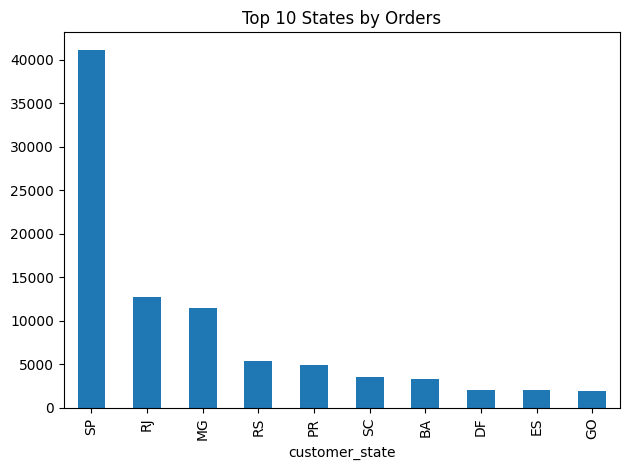

In [30]:
state_orders = c_d.merge(clean_values, on='customer_id')
state_orders['customer_state'].value_counts().head(10).plot(kind='bar', title='Top 10 States by Orders')
plt.tight_layout()
plt.show()

1. São Paulo alone accounts for the majority of orders, which suggests Olist's customer base is geographically dependent on SP, leaving significant untapped potential in other states

## Testing Hypothesis 

1. Testing hypothesis for delivery chart

In [31]:
from scipy import stats

on_time = master_df[master_df['actual_delivery_date'] <= 0]['review_score'].dropna()
late = master_df[master_df['actual_delivery_date'] > 0]['review_score'].dropna()

stat, p = stats.mannwhitneyu(on_time, late, alternative='greater')
print(f"Mann-Whitney U stat: {stat}")
print(f"P-value: {p}")

Mann-Whitney U stat: 639521940.5
P-value: 0.0


- H0: Late delivery does not have any negative impact on the review score.
- H1: Late delivery does have a negative impact on the review score.
- Test used: Mann-Whitney U
- P-value: 0.0
- Result: Reject H0. Late delivery does have a negative impact on the review score.

2. Testing hypothesis for payment chart

In [32]:
credit = master_df[master_df['payment_type'] == 'credit_card']['payment_value'].dropna()
boleto = master_df[master_df['payment_type'] == 'boleto']['payment_value'].dropna()

stat2, p2 = stats.mannwhitneyu(credit, boleto, alternative='greater')
print(f"Mann-Whitney U stat: {stat2}")
print(f"P-value: {p2}")

Mann-Whitney U stat: 1045444472.5
P-value: 1.8821805701429077e-32


- H0: Credit card transactions does not have significantly higher payment values than boleto transactions.
- H1: Credit card transactions have significantly higher payment values than boleto transactions.
- Test used: Mann-Whitney U
- P-value: 1.88e-32
- Result: Reject H0. Credit card transactions have significantly higher payment values than boleto transactions.

## Actionables

### Actionable 1:

- Action: Improve delivery monitoring and implement early delay notifications for customers.
- Based on: The hypothesis test showed that late deliveries significantly reduce review scores (p-value ≈ 0), indicating that delivery performance strongly impacts customer satisfaction.
- Expected outcome: Improved customer reviews, better customer satisfaction, and reduced negative feedback.

### Actionable 2:

- Action: Launch personalized loyalty programs and post-purchase email campaigns for first-time buyers.
- Based on: The repeat customer analysis showed that only 3.12% of customers placed more than one order, meaning most customers never return to the platform.
- Expected outcome: Increased repeat purchases, higher customer retention, and improved customer lifetime value.

The current dataset cannot answer this because it contains no browsing, session, or post-review activity data — only completed orders. So we can see a customer never ordered again, but we cannot tell if they returned and didn't buy, or left the platform entirely. This matters because the answer determines whether Olist should invest in review recovery campaigns or focus purely on new customer acquisition.